# Part B — Email Spam Classification Using Existing Word-Count Features

**Improvements over the first version**
- Robust target conversion (fixes the `Numeric target must contain only 0 and 1` error).
- Duplicate emails removed before splitting (they inflate test scores).
- All feature filtering (constant / rare / common words) is fitted on the **training set only**.
- **Class imbalance is handled** with class weights (`class_weight="balanced"`, `fit_prior=False` for Naive Bayes). Baseline (unbalanced) models are kept for comparison.
- `log1p` transform of counts for Logistic Regression and Linear SVM (fixes convergence problems; not TF-IDF).
- Stratified 5-fold cross-validation and hyper-parameter tuning, optimising F1 of the spam class.
- Extra metrics that are meaningful under imbalance: Balanced Accuracy, MCC, ROC-AUC, PR-AUC.

## Cell 1 — Import Libraries

In [1]:
import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score, matthews_corrcoef,
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report
)

warnings.filterwarnings("ignore", category=FutureWarning)
RANDOM_STATE = 42

print("Libraries imported successfully.")

Libraries imported successfully.


## Cell 2 — Set Dataset Path

Change `EMAIL_DATASET_PATH` to your CSV or Excel file.

In [2]:
EMAIL_DATASET_PATH = r"C:\\Users\\Yatri\\Desktop\\ml_lab06\\archive (2)\\emails.csv"

print("Dataset path:", EMAIL_DATASET_PATH)
print("File exists:", os.path.exists(EMAIL_DATASET_PATH))

Dataset path: C:\\Users\\Yatri\\Desktop\\ml_lab06\\archive (2)\\emails.csv
File exists: True


## Cell 3 — Load Dataset

In [3]:
if not os.path.exists(EMAIL_DATASET_PATH):
    raise FileNotFoundError("Update EMAIL_DATASET_PATH with the correct dataset location.")

extension = os.path.splitext(EMAIL_DATASET_PATH)[1].lower()

if extension == ".csv":
    df = pd.read_csv(EMAIL_DATASET_PATH)
elif extension in [".xlsx", ".xls"]:
    df = pd.read_excel(EMAIL_DATASET_PATH)
else:
    raise ValueError("Use a CSV or Excel dataset.")

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (5172, 3002)


,Email No.,the,to,ect,and,for,of,a,you,hou,...,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry,Prediction
0,Email 1,0,0,1,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Email 2,8,13,24,6,6,2,102,1,27,...,0,0,0,0,0,0,0,1,0,0
2,Email 3,0,0,1,0,0,0,8,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Email 4,0,5,22,0,5,1,51,2,10,...,0,0,0,0,0,0,0,0,0,0
4,Email 5,7,6,17,1,5,2,57,0,9,...,0,0,0,0,0,0,0,1,0,0


## Cell 4 — Inspect Dataset

In [4]:
print("Columns (first 20):")
print(df.columns.tolist()[:20])

print("\nData types (count per dtype):")
display(df.dtypes.astype(str).value_counts())

print("\nMissing values (top 20 columns):")
display(df.isnull().sum().sort_values(ascending=False).head(20))

print("Fully duplicated rows:", df.duplicated().sum())

Columns (first 20):
['Email No.', 'the', 'to', 'ect', 'and', 'for', 'of', 'a', 'you', 'hou', 'in', 'on', 'is', 'this', 'enron', 'i', 'be', 'that', 'will', 'have']

Data types (count per dtype):


int64    3001
str         1
Name: count, dtype: int64


Missing values (top 20 columns):


Email No.    0
the          0
to           0
ect          0
and          0
for          0
of           0
a            0
you          0
hou          0
in           0
on           0
is           0
this         0
enron        0
i            0
be           0
that         0
will         0
have         0
dtype: int64

Fully duplicated rows: 0


## Cell 5 — Select Target Column

If automatic detection fails, replace `None` with your actual target column name.

In [5]:
TARGET_COLUMN = None

if TARGET_COLUMN is None:
    # Priority order. "spam" is last because in word-count datasets it is often
    # just the COUNT of the word "spam", not the label.
    priority = ["prediction", "label", "labels", "class", "target", "category",
                "is_spam", "spam_label", "v1", "spam"]
    lower_to_col = {str(c).strip().lower(): c for c in df.columns}

    for name in priority:
        col = lower_to_col.get(name)
        # a real spam/non-spam target has exactly 2 distinct values
        if col is not None and df[col].nunique(dropna=True) == 2:
            TARGET_COLUMN = col
            break

    if TARGET_COLUMN is None:
        raise ValueError(
            "Target not detected (no candidate column with exactly 2 classes). "
            "Set TARGET_COLUMN manually, e.g. TARGET_COLUMN = 'Prediction'."
        )

print("Target column:", TARGET_COLUMN)
print("Target dtype :", df[TARGET_COLUMN].dtype)
print("\nClass distribution:")
print(df[TARGET_COLUMN].value_counts(dropna=False))

Target column: Prediction
Target dtype : int64

Class distribution:
Prediction
0    3672
1    1500
Name: count, dtype: int64


## Cell 6 — Visualize Spam / Non-Spam Distribution

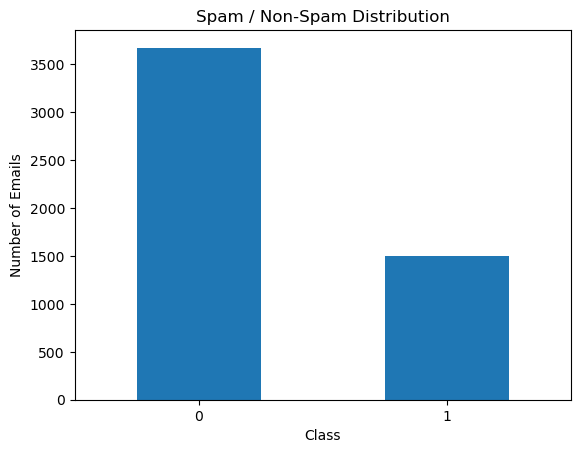

Prediction
0    71.0
1    29.0
Name: Percentage, dtype: float64

Imbalance ratio (majority : minority) = 2.45 : 1


In [6]:
counts = df[TARGET_COLUMN].value_counts()
counts.plot(kind="bar")
plt.title("Spam / Non-Spam Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Emails")
plt.xticks(rotation=0)
plt.show()

display(
    (df[TARGET_COLUMN].value_counts(normalize=True) * 100)
    .round(2).rename("Percentage")
)

if len(counts) == 2:
    print(f"Imbalance ratio (majority : minority) = {counts.max() / counts.min():.2f} : 1")

## Cell 7 — Convert Target to 0/1

`1 = Spam` and `0 = Non-Spam`.

The conversion works for string, category, boolean and numeric label columns, and drops rows whose label is missing.
If your labels are something unusual (for example `1/2`), set `SPAM_LABEL` to the value that means spam.

In [7]:
# Only set this if automatic mapping fails, e.g. SPAM_LABEL = 2  or  SPAM_LABEL = "junk"
SPAM_LABEL = None

SPAM = {"spam", "1", "1.0", "true", "yes", "y", "t"}
HAM = {"ham", "non-spam", "nonspam", "non spam", "not spam", "notspam",
       "legitimate", "0", "0.0", "false", "no", "n", "f"}

# Drop rows with a missing target so that X and y stay aligned
n_missing = int(df[TARGET_COLUMN].isna().sum())
if n_missing:
    print(f"Dropping {n_missing} rows with missing target")
    df = df.dropna(subset=[TARGET_COLUMN]).copy()

y_text = df[TARGET_COLUMN].astype(str).str.strip().str.lower()
unique_labels = set(y_text.unique())

if SPAM_LABEL is not None:
    y = (y_text == str(SPAM_LABEL).strip().lower()).astype(int)
elif unique_labels <= (SPAM | HAM):
    y = y_text.map(lambda v: 1 if v in SPAM else 0).astype(int)
else:
    raise ValueError(
        f"Unrecognized labels: {sorted(unique_labels)}. "
        "Set SPAM_LABEL to the value that means spam."
    )

print(y.value_counts())
print("Mapping: 0 = Non-Spam, 1 = Spam")

Prediction
0    3672
1    1500
Name: count, dtype: int64
Mapping: 0 = Non-Spam, 1 = Spam


## Cell 8 — Identify Existing Word-Count Features

The dataset is already vectorized. We therefore use its numerical columns directly.

Obvious ID columns are removed because they are not word features.

In [8]:
feature_df = df.drop(columns=[TARGET_COLUMN]).copy()

id_columns = []
for col in feature_df.columns:
    name = str(col).lower().strip()
    if name in {
        "id", "email_id", "emailid", "email no.", "email no", "message_id",
        "messageid", "index", "unnamed: 0"
    }:
        id_columns.append(col)

feature_df = feature_df.drop(columns=id_columns, errors="ignore")

X = feature_df.select_dtypes(include=[np.number]).copy()
X = X.fillna(0)

print("ID columns removed:", id_columns)
print("Existing numeric word-count features:", X.shape[1])
print("Minimum value in feature matrix:", X.min().min(), "(must be >= 0 for Naive Bayes)")
display(X.head())

ID columns removed: ['Email No.', 'id', 'index']
Existing numeric word-count features: 2998
Minimum value in feature matrix: 0 (must be >= 0 for Naive Bayes)


,the,to,ect,and,for,of,a,you,hou,in,...,enhancements,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry
0,0,0,1,0,0,0,2,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,8,13,24,6,6,2,102,1,27,18,...,0,0,0,0,0,0,0,0,1,0
2,0,0,1,0,0,0,8,0,0,4,...,0,0,0,0,0,0,0,0,0,0
3,0,5,22,0,5,1,51,2,10,1,...,0,0,0,0,0,0,0,0,0,0
4,7,6,17,1,5,2,57,0,9,3,...,0,0,0,0,0,0,0,0,1,0


## Cell 9 — Remove Duplicate Emails

Identical word-count rows with the same label appear in both train and test sets otherwise, which inflates the scores.

In [9]:
before = len(X)
dup_mask = pd.concat([X, y.rename("__target__")], axis=1).duplicated(keep="first")
X = X.loc[~dup_mask]
y = y.loc[~dup_mask]

print(f"Duplicate rows removed: {before - len(X)}  ({before} -> {len(X)})")
print("Same features but different label (conflicting rows):", int(X.duplicated().sum()))
print("\nClass distribution after de-duplication:")
print(y.value_counts())

Duplicate rows removed: 541  (5172 -> 4631)
Same features but different label (conflicting rows): 0

Class distribution after de-duplication:
Prediction
0    3170
1    1461
Name: count, dtype: int64


## Cell 10 — Train/Test Split

The split is performed **before** any feature filtering (constant / rare / common words) to avoid data leakage.
`stratify=y` keeps the same spam ratio in both sets (it does not balance the classes; that is done later).

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Training features:", X_train.shape[1])
print("\nTraining class distribution:")
print(y_train.value_counts())
print("\nTesting class distribution:")
print(y_test.value_counts())

Training samples: 3704
Testing samples: 927
Training features: 2998

Training class distribution:
Prediction
0    2535
1    1169
Name: count, dtype: int64

Testing class distribution:
Prediction
0    635
1    292
Name: count, dtype: int64


## Cell 11 — Remove Constant Features

A word column with exactly the same value in every training email carries no information. Computed on the training set only.

In [11]:
constant_columns = X_train.columns[X_train.nunique(dropna=False) <= 1]
X_train = X_train.drop(columns=constant_columns)
X_test = X_test.drop(columns=constant_columns)

print("Constant features removed:", len(constant_columns))
print("Features remaining:", X_train.shape[1])

Constant features removed: 0
Features remaining: 2998


## Cell 12 — Remove Rare Word Features

A feature must appear in at least 2 training emails.

This is the direct equivalent of applying a `min_df`-type idea to an already-vectorized count matrix.

In [20]:
MIN_DOCUMENT_FREQUENCY = 10

document_frequency = (X_train > 0).sum(axis=0)
keep = document_frequency[document_frequency >= MIN_DOCUMENT_FREQUENCY].index

n_before = X_train.shape[1]
X_train = X_train[keep].copy()
X_test = X_test[keep].copy()

print("Rare features removed:", n_before - X_train.shape[1])
print("Features after rare-word filtering:", X_train.shape[1])

Rare features removed: 79
Features after rare-word filtering: 2892


## Cell 13 — Remove Extremely Common Word Features

Words appearing in more than 95% of training emails are removed.

Set `MAX_DOCUMENT_FREQUENCY_RATIO = 1.0` if you want to skip this step.

In [21]:
MAX_DOCUMENT_FREQUENCY_RATIO = 0.95

n_before = X_train.shape[1]
if MAX_DOCUMENT_FREQUENCY_RATIO < 1.0:
    max_df = MAX_DOCUMENT_FREQUENCY_RATIO * len(X_train)
    document_frequency = (X_train > 0).sum(axis=0)
    keep = document_frequency[document_frequency <= max_df].index

    X_train = X_train[keep].copy()
    X_test = X_test[keep].copy()

print("Common features removed:", n_before - X_train.shape[1])
print("Final number of word-count features:", X_train.shape[1])

Common features removed: 0
Final number of word-count features: 2892


## Cell 14 — Final Count Representation

No TF-IDF is applied. The final matrices are the existing word-count representation after preprocessing.

Because raw counts are heavily skewed (a few words have very large counts), Logistic Regression and Linear SVM are given `log1p(count)`, which usually fixes convergence problems. It is a simple element-wise transform with nothing fitted, so it cannot leak information. Multinomial Naive Bayes keeps the raw counts.

In [22]:
X_train_log = np.log1p(X_train)
X_test_log = np.log1p(X_test)

FEATURES = {
    "Multinomial Naive Bayes": (X_train, X_test),
    "Logistic Regression": (X_train_log, X_test_log),
    "Linear SVM": (X_train_log, X_test_log),
}

print("Final training shape:", X_train.shape)
print("Final testing shape:", X_test.shape)
display(X_train.head())

Final training shape: (3704, 2892)
Final testing shape: (927, 2892)


,the,to,and,for,of,you,hou,in,on,is,...,enhancements,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry
2179,0,2,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
253,9,4,0,5,6,0,0,10,6,0,...,0,0,0,0,0,0,0,0,0,0
1616,3,2,0,3,1,2,0,5,4,0,...,0,0,0,0,0,0,0,0,0,0
1212,7,3,1,3,0,3,2,0,4,2,...,0,0,0,0,0,0,0,0,0,0
2284,0,2,0,0,0,1,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0


## Cell 15 — Helper Functions

- `make_model` builds each classifier with or without class balancing.
  - Logistic Regression and Linear SVM: `class_weight="balanced"`.
  - Multinomial Naive Bayes has no `class_weight`, so `fit_prior=False` is used (uniform class prior).
- `evaluate` computes accuracy, precision, recall, F1, balanced accuracy, MCC, ROC-AUC and PR-AUC on the test set, plus training and prediction time.

In [23]:
MODEL_NAMES = ["Multinomial Naive Bayes", "Logistic Regression", "Linear SVM"]


def make_model(name, balanced, **params):
    if name == "Multinomial Naive Bayes":
        return MultinomialNB(fit_prior=not balanced, **params)
    if name == "Logistic Regression":
        return LogisticRegression(
            max_iter=2000, random_state=RANDOM_STATE,
            class_weight="balanced" if balanced else None, **params
        )
    if name == "Linear SVM":
        return LinearSVC(
            max_iter=10000, random_state=RANDOM_STATE,
            class_weight="balanced" if balanced else None, **params
        )
    raise ValueError(name)


def get_scores(model, X):
    # continuous spam score used for ROC-AUC / PR-AUC
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    return model.decision_function(X)


def evaluate(name, setting, model, X_te, train_time):
    # prediction time = average of 5 runs (a single run is too noisy)
    times = []
    for _ in range(5):
        start = time.perf_counter()
        y_pred = model.predict(X_te)
        times.append(time.perf_counter() - start)

    scores = get_scores(model, X_te)
    return {
        "Model": name,
        "Setting": setting,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
        "MCC": matthews_corrcoef(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, scores),
        "PR-AUC": average_precision_score(y_test, scores),
        "Training Time (s)": train_time,
        "Prediction Time (s)": float(np.mean(times)),
        "Number of Features": X_test.shape[1],
    }


results = []
trained_models = {}   # key = (model name, setting)
print("Helpers defined.")

Helpers defined.


In [24]:
print("Target column:", TARGET_COLUMN)
print((y.value_counts(normalize=True) * 100).round(2))

baseline = y_test.value_counts(normalize=True).max()
print(f"\nMajority-class baseline accuracy: {baseline:.4f}")

for (name, setting), model in trained_models.items():
    X_tr, X_te = FEATURES[name]
    print(f"{name:25s} {setting:18s} "
          f"train F1={f1_score(y_train, model.predict(X_tr)):.3f}  "
          f"test F1={f1_score(y_test, model.predict(X_te)):.3f}  "
          f"test recall={recall_score(y_test, model.predict(X_te)):.3f}")

Target column: Prediction
Prediction
0    68.45
1    31.55
Name: proportion, dtype: float64

Majority-class baseline accuracy: 0.6850


## Cell 16 — Train Models: Baseline (Unbalanced) vs Class-Balanced

Same models, same data; the only difference is class balancing. This shows the effect of handling the imbalance.

In [25]:
for setting, balanced in [("Baseline", False), ("Class-balanced", True)]:
    for name in MODEL_NAMES:
        X_tr, X_te = FEATURES[name]
        model = make_model(name, balanced)

        start = time.perf_counter()
        model.fit(X_tr, y_train)
        train_time = time.perf_counter() - start

        results.append(evaluate(name, setting, model, X_te, train_time))
        trained_models[(name, setting)] = model

display(pd.DataFrame(results).drop(columns=["Number of Features"]).round(4))

,Model,Setting,Accuracy,Precision,Recall,F1 Score,Balanced Accuracy,MCC,ROC-AUC,PR-AUC,Training Time (s),Prediction Time (s)
0,Multinomial Naive Bayes,Baseline,0.9558,0.8934,0.9760,0.9329,0.9612,0.9020,0.9811,0.9295,0.0412,0.0312
1,Logistic Regression,Baseline,0.9709,0.9522,0.9555,0.9538,0.9667,0.9326,0.9969,0.9935,0.2768,0.0180
2,Linear SVM,Baseline,0.9655,0.9452,0.9452,0.9452,0.9600,0.9200,0.9945,0.9895,0.2587,0.0156
3,Multinomial Naive Bayes,Class-balanced,0.9547,0.8882,0.9795,0.9316,0.9614,0.9002,0.9812,0.9303,0.0292,0.0289
4,Logistic Regression,Class-balanced,0.9752,0.9439,0.9795,0.9613,0.9763,0.9434,0.9969,0.9936,0.2979,0.0147
5,Linear SVM,Class-balanced,0.9644,0.9481,0.9384,0.9432,0.9574,0.9173,0.9944,0.9894,0.5455,0.0206


## Cell 17 — Hyper-parameter Tuning with Stratified 5-Fold Cross-Validation

Tuning is done on the **training set only**, using the F1 score of the spam class. The test set is untouched until the final evaluation.
The mean ± std of the cross-validated F1 shows how stable each model is (a single split is noisy when the spam class is small).

In [27]:
param_grids = {
       "Multinomial Naive Bayes": {"alpha": [0.01, 0.1, 0.5, 1.0, 2.0]},
       "Logistic Regression": {"C": [0.01, 0.03, 0.1, 0.3, 1, 10]},
       "Linear SVM": {"C": [0.001, 0.003, 0.01, 0.03, 0.1, 1]},
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_summary = []

for name in MODEL_NAMES:
    X_tr, X_te = FEATURES[name]

    search = GridSearchCV(
        make_model(name, balanced=True),
        param_grids[name],
        scoring="f1",
        cv=cv,
        n_jobs=-1,
        refit=True,
    )
    search.fit(X_tr, y_train)

    best = search.best_index_
    cv_summary.append({
        "Model": name,
        "Best Params": search.best_params_,
        "CV F1 (mean)": search.cv_results_["mean_test_score"][best],
        "CV F1 (std)": search.cv_results_["std_test_score"][best],
    })

    setting = "Balanced + tuned"
    results.append(evaluate(name, setting, search.best_estimator_, X_te, search.refit_time_))
    trained_models[(name, setting)] = search.best_estimator_

display(pd.DataFrame(cv_summary).round(4))

,Model,Best Params,CV F1 (mean),CV F1 (std)
0,Multinomial Naive Bayes,{'alpha': 0.01},0.9379,0.0096
1,Logistic Regression,{'C': 1},0.9532,0.0048
2,Linear SVM,{'C': 0.03},0.9516,0.0053


## Cell 18 — Detailed Classification Reports (Balanced + Tuned Models)

In [18]:
for name in MODEL_NAMES:
    model = trained_models[(name, "Balanced + tuned")]
    y_pred = model.predict(FEATURES[name][1])

    print("=" * 70)
    print(name, "| Balanced + tuned")
    print("=" * 70)
    print(classification_report(
        y_test, y_pred,
        target_names=["Non-Spam", "Spam"],
        zero_division=0
    ))

Multinomial Naive Bayes | Balanced + tuned
              precision    recall  f1-score   support

    Non-Spam       0.99      0.95      0.97       635
        Spam       0.91      0.98      0.94       292

    accuracy                           0.96       927
   macro avg       0.95      0.97      0.96       927
weighted avg       0.96      0.96      0.96       927

Logistic Regression | Balanced + tuned
              precision    recall  f1-score   support

    Non-Spam       0.99      0.97      0.98       635
        Spam       0.94      0.98      0.96       292

    accuracy                           0.97       927
   macro avg       0.97      0.98      0.97       927
weighted avg       0.97      0.97      0.97       927

Linear SVM | Balanced + tuned
              precision    recall  f1-score   support

    Non-Spam       0.99      0.96      0.98       635
        Spam       0.93      0.98      0.95       292

    accuracy                           0.97       927
   macro avg    

## Cell 19 — Confusion Matrices

Rows = setting, columns = model. Compare the top row (baseline) with the bottom row (balanced + tuned): balancing should reduce missed spam (bottom-left of the spam row).

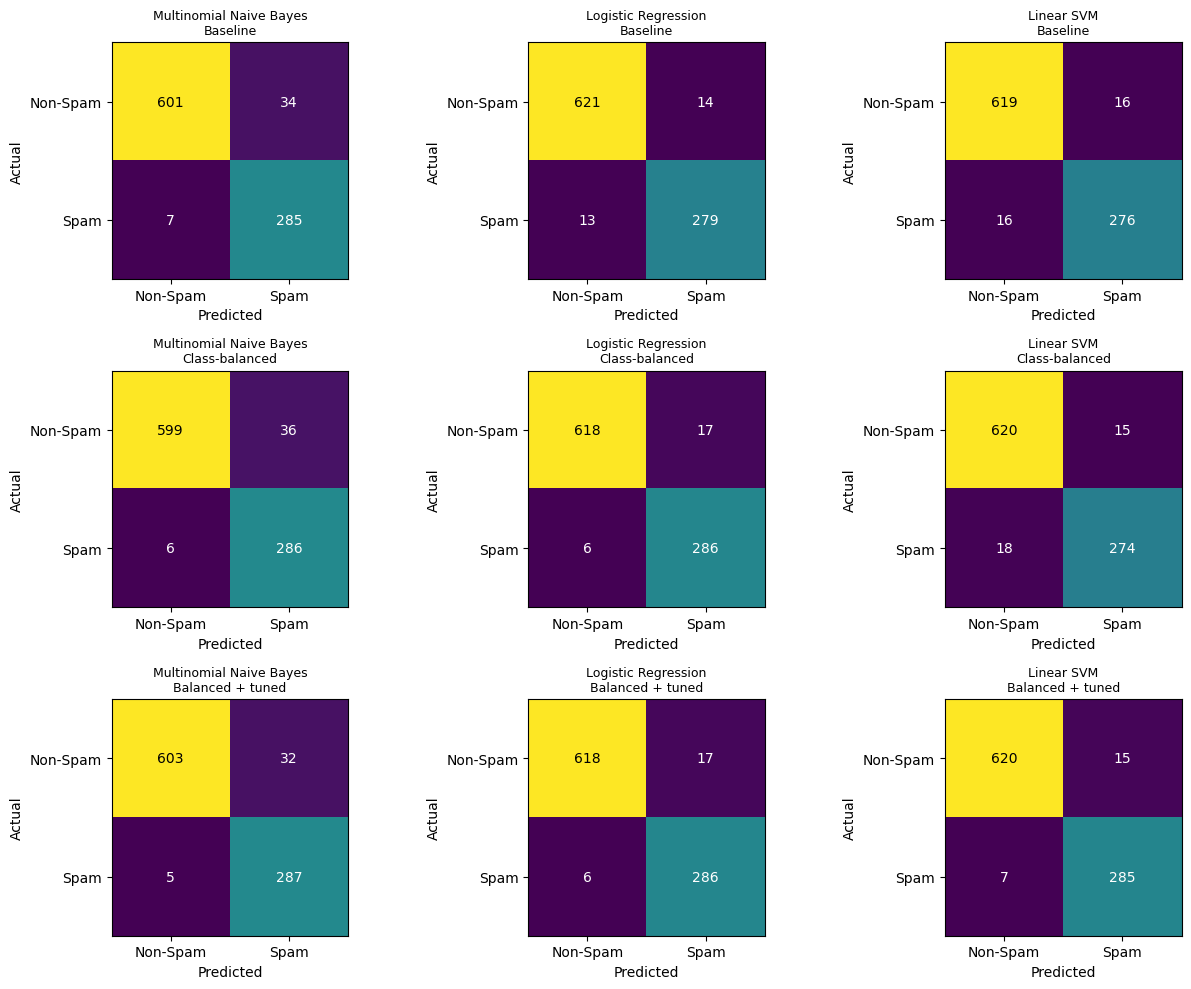

In [28]:
settings = ["Baseline", "Class-balanced", "Balanced + tuned"]
fig, axes = plt.subplots(len(settings), len(MODEL_NAMES), figsize=(13, 10))

for r, setting in enumerate(settings):
    for c, name in enumerate(MODEL_NAMES):
        model = trained_models[(name, setting)]
        cm = confusion_matrix(y_test, model.predict(FEATURES[name][1]))
        ax = axes[r, c]
        ax.imshow(cm)
        ax.set_title(f"{name}\n{setting}", fontsize=9)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
        ax.set_xticks([0, 1]); ax.set_xticklabels(["Non-Spam", "Spam"])
        ax.set_yticks([0, 1]); ax.set_yticklabels(["Non-Spam", "Spam"])
        for i in range(2):
            for j in range(2):
                ax.text(j, i, cm[i, j], ha="center", va="center",
                        color="white" if cm[i, j] < cm.max() / 2 else "black")

plt.tight_layout()
plt.show()

## Cell 20 — Compare Predictive Performance

Accuracy  Precision  Recall  \
Model                   Setting                                         
Linear SVM              Baseline            0.9655     0.9452  0.9452   
                        Class-balanced      0.9644     0.9481  0.9384   
                        Balanced + tuned    0.9763     0.9500  0.9760   
                        Balanced + tuned    0.9763     0.9500  0.9760   
Logistic Regression     Baseline            0.9709     0.9522  0.9555   
                        Class-balanced      0.9752     0.9439  0.9795   
                        Balanced + tuned    0.9752     0.9439  0.9795   
                        Balanced + tuned    0.9752     0.9439  0.9795   
Multinomial Naive Bayes Baseline            0.9558     0.8934  0.9760   
                        Class-balanced      0.9547     0.8882  0.9795   
                        Balanced + tuned    0.9601     0.8997  0.9829   
                        Balanced + tuned    0.9601     0.8997  0.9829   

                                          F1 Score  Balanced Accuracy     MCC  \
Model                   Setting                                                 
Linear SVM              Baseline            0.9452             0.9600  0.9200   
                        Class-balanced      0.9432             0.9574  0.9173   
                        Balanced + tuned    0.9628             0.9762  0.9456   
                        Balanced + tuned    0.9628             0.9762  0.9456   
Logistic Regression     Baseline            0.9538             0.9667  0.9326   
                        Class-balanced      0.9613             0.9763  0.9434   
                        Balanced + tuned    0.9613             0.9763  0.9434   
                        Balanced + tuned    0.9613             0.9763  0.9434   
Multinomial Naive Bayes Baseline            0.9329             0.9612  0.9020   
                        Class-balanced      0.9316             0.9614  0.9002   
                        Balanced + tuned    0.9394             0.9662  0.9117   
                        Balanced + tuned    0.9394             0.9662  0.9117   

                                          ROC-AUC  PR-AUC  
Model                   Setting                            
Linear SVM              Baseline           0.9945  0.9895  
                        Class-balanced     0.9944  0.9894  
                        Balanced + tuned   0.9965  0.9925  
                        Balanced + tuned   0.9965  0.9925  
Logistic Regression     Baseline           0.9969  0.9935  
                        Class-balanced     0.9969  0.9936  
                        Balanced + tuned   0.9969  0.9936  
                        Balanced + tuned   0.9969  0.9936  
Multinomial Naive Bayes Baseline           0.9811  0.9295  
                        Class-balanced     0.9812  0.9303  
                        Balanced + tuned   0.9855  0.9461  
                        Balanced + tuned   0.9855  0.9461

ValueError: Index contains duplicate entries, cannot reshape

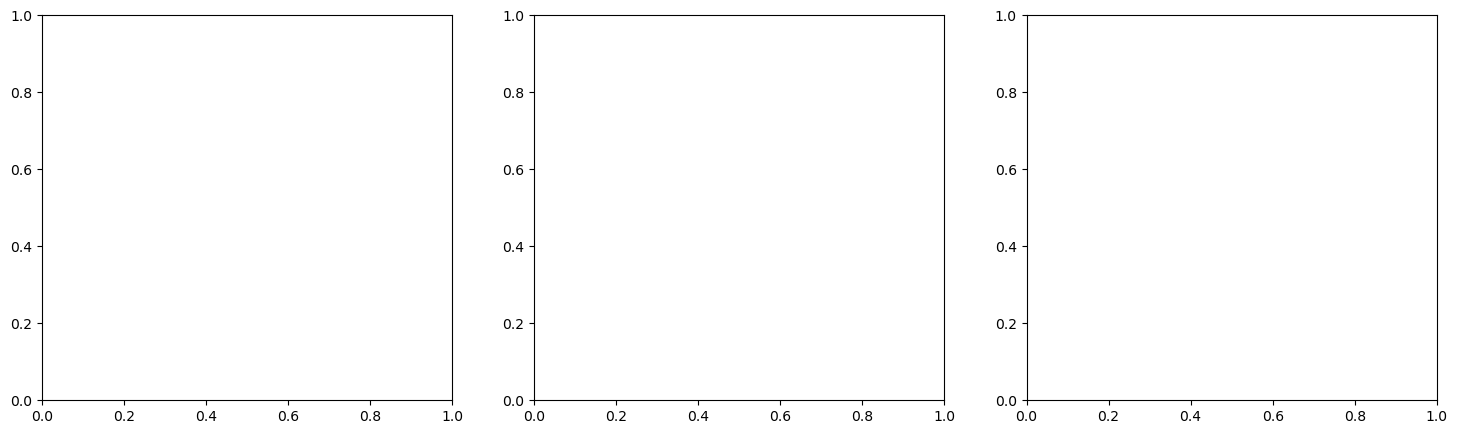

In [29]:
results_df = pd.DataFrame(results)
setting_order = ["Baseline", "Class-balanced", "Balanced + tuned"]
results_df["Setting"] = pd.Categorical(results_df["Setting"], categories=setting_order, ordered=True)
results_df = results_df.sort_values(["Model", "Setting"]).reset_index(drop=True)

metric_cols = ["Accuracy", "Precision", "Recall", "F1 Score",
               "Balanced Accuracy", "MCC", "ROC-AUC", "PR-AUC"]
display(results_df.set_index(["Model", "Setting"])[metric_cols].round(4))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, metric in zip(axes, ["Recall", "F1 Score", "PR-AUC"]):
    (results_df.pivot(index="Model", columns="Setting", values=metric)[setting_order]
        .plot(kind="bar", ax=ax))
    ax.set_title(f"{metric} (spam class)")
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

## Cell 21 — Compare Training Time, Prediction Time, and Feature Count

In [ ]:
display(
    results_df[["Model", "Setting", "Number of Features",
                "Training Time (s)", "Prediction Time (s)"]].round(6)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col in zip(axes, ["Training Time (s)", "Prediction Time (s)"]):
    (results_df.pivot(index="Model", columns="Setting", values=col)[setting_order]
        .plot(kind="bar", ax=ax))
    ax.set_ylabel("Time (seconds)")
    ax.set_title(col)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

## Cell 22 — Final Results Table

In [30]:
final_results = results_df[[
    "Model", "Setting", "Number of Features", "Accuracy", "Precision", "Recall",
    "F1 Score", "Balanced Accuracy", "MCC", "ROC-AUC", "PR-AUC",
    "Training Time (s)", "Prediction Time (s)"
]]

display(final_results.round(5))

best = final_results.sort_values("F1 Score", ascending=False).iloc[0]
print(f"Best F1 on the test set: {best['Model']} ({best['Setting']}) -> F1 = {best['F1 Score']:.4f}")

,Model,Setting,Number of Features,Accuracy,Precision,Recall,F1 Score,Balanced Accuracy,MCC,ROC-AUC,PR-AUC,Training Time (s),Prediction Time (s)
0,Linear SVM,Baseline,2892,0.96548,0.94521,0.94521,0.94521,0.96000,0.92001,0.99446,0.98953,0.25873,0.01556
1,Linear SVM,Class-balanced,2892,0.96440,0.94810,0.93836,0.94320,0.95737,0.91731,0.99436,0.98942,0.54549,0.02056
2,Linear SVM,Balanced + tuned,2892,0.97627,0.95000,0.97603,0.96284,0.97620,0.94560,0.99655,0.99252,0.19000,0.01747
3,Linear SVM,Balanced + tuned,2892,0.97627,0.95000,0.97603,0.96284,0.97620,0.94560,0.99655,0.99252,0.19914,0.02757
4,Logistic Regression,Baseline,2892,0.97087,0.95222,0.95548,0.95385,0.96672,0.93257,0.99691,0.99353,0.27679,0.01803
5,Logistic Regression,Class-balanced,2892,0.97519,0.94389,0.97945,0.96134,0.97634,0.94343,0.99694,0.99358,0.29793,0.01473
6,Logistic Regression,Balanced + tuned,2892,0.97519,0.94389,0.97945,0.96134,0.97634,0.94343,0.99694,0.99358,0.42072,0.01936
7,Logistic Regression,Balanced + tuned,2892,0.97519,0.94389,0.97945,0.96134,0.97634,0.94343,0.99694,0.99358,0.37440,0.01624
8,Multinomial Naive Bayes,Baseline,2892,0.95577,0.89342,0.97603,0.93290,0.96124,0.90197,0.98109,0.92951,0.04117,0.03122
9,Multinomial Naive Bayes,Class-balanced,2892,0.95469,0.88820,0.97945,0.93160,0.96138,0.90025,0.98123,0.93032,0.02917,0.02889


Best F1 on the test set: Linear SVM (Balanced + tuned) -> F1 = 0.9628
